In [ ]:
import gc

gc.collect()


4

In [ ]:
#!pip install scikit-multilearn

In [ ]:
#!pip install pyarrow

In [ ]:
#!pip install scikit-multilearn

In [ ]:
#!pip install iterative-stratification

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Import Dependencies

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.multioutput import MultiOutputClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, classification_report
#from skmultilearn.model_selection import iterative_train_test_split
from sklearn.multioutput import ClassifierChain
from sklearn.metrics import classification_report, roc_auc_score
#from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, f1_score, recall_score, precision_score
from sklearn.metrics import (
    make_scorer, recall_score, f1_score, precision_score,
    roc_auc_score, hamming_loss, label_ranking_average_precision_score,
    multilabel_confusion_matrix, classification_report)

from xgboost import XGBClassifier
import re
from sklearn.metrics import f1_score, accuracy_score
from sklearn.metrics import label_ranking_average_precision_score
from sklearn.metrics import f1_score, accuracy_score, label_ranking_average_precision_score
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, label_ranking_average_precision_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Reading Dataset Columns

In [ ]:

csv_path = '/content/drive/MyDrive/TMU_DM_Med_Jan2025R1.csv'

#  Read only the header (column names)
df1 = pd.read_csv(csv_path, nrows=0)
raw_cols = df1.columns.to_list()
print(len(raw_cols))
raw_cols

363


['Age_at_Exam',
 'Sex',
 'sBP',
 'sBP_Date',
 'BMI',
 'BMI_Date',
 'LDL',
 'LDL_Date',
 'HDL',
 'HDL_Date',
 'A1c',
 'A1c_Date',
 'TG',
 'TG_Date',
 'FBS',
 'FBS_Date',
 'Total_Cholesterol',
 'Total_Cholesterol_Lab_Date',
 'Diabetes',
 'Depression',
 'Depression_OnsetDate',
 'HTN',
 'HTN_OnsetDate',
 'OA',
 'OA_OnsetDate',
 'COPD',
 'COPD_Date',
 'Patient_ID',
 'DM_OnsetDate',
 'DM_Onset_Revised_1YrPrior',
 '[Amputation)',
 '[Amputation_Date]',
 '[Anxiety)',
 '[Anxiety_Date]',
 '[Arrhythmia)',
 '[Arrhythmia_Date]',
 '[AtrialFibrillation)',
 '[AtrialFibrillation_Date]',
 '[Blindness)',
 '[Blindness_Date]',
 '[CABG)',
 '[CABG_Date]',
 '[CAD)',
 '[CAD_Date]',
 '[Cancer)',
 '[Cancer_Date]',
 '[Cardiomyopathy)',
 '[Cardiomyopathy_Date]',
 '[Cataract)',
 '[Cataract_Date]',
 '[CKD)',
 '[CKD_Date]',
 '[Deceased)',
 '[Deceased_Date]',
 '[Depression)',
 '[Depression_Date]',
 '[DiabeticFootUlcer)',
 '[DiabeticFootUlcer_Date]',
 '[Dialysis)',
 '[Dialysis_Date]',
 '[Enteropathy)',
 '[Enteropathy_Da

# Fixing Column Names

In [ ]:
def clean(col):
    col = re.sub(r"[\[\]\(\)]", "", col) # if replace with "" there would be two columns with name Depression
    #col = re.sub(r"[ /-]", "_", col)
    return col

clean_cols = [clean(col) for col in raw_cols]
print(len(clean_cols))
clean_cols

363


['Age_at_Exam',
 'Sex',
 'sBP',
 'sBP_Date',
 'BMI',
 'BMI_Date',
 'LDL',
 'LDL_Date',
 'HDL',
 'HDL_Date',
 'A1c',
 'A1c_Date',
 'TG',
 'TG_Date',
 'FBS',
 'FBS_Date',
 'Total_Cholesterol',
 'Total_Cholesterol_Lab_Date',
 'Diabetes',
 'Depression',
 'Depression_OnsetDate',
 'HTN',
 'HTN_OnsetDate',
 'OA',
 'OA_OnsetDate',
 'COPD',
 'COPD_Date',
 'Patient_ID',
 'DM_OnsetDate',
 'DM_Onset_Revised_1YrPrior',
 'Amputation',
 'Amputation_Date',
 'Anxiety',
 'Anxiety_Date',
 'Arrhythmia',
 'Arrhythmia_Date',
 'AtrialFibrillation',
 'AtrialFibrillation_Date',
 'Blindness',
 'Blindness_Date',
 'CABG',
 'CABG_Date',
 'CAD',
 'CAD_Date',
 'Cancer',
 'Cancer_Date',
 'Cardiomyopathy',
 'Cardiomyopathy_Date',
 'Cataract',
 'Cataract_Date',
 'CKD',
 'CKD_Date',
 'Deceased',
 'Deceased_Date',
 'Depression',
 'Depression_Date',
 'DiabeticFootUlcer',
 'DiabeticFootUlcer_Date',
 'Dialysis',
 'Dialysis_Date',
 'Enteropathy',
 'Enteropathy_Date',
 'ESRD',
 'ESRD_Date',
 'Gangrene',
 'Gangrene_Date',
 'Ga

# Fixing Duplicate column Names

In [ ]:
duplicates = pd.Series(clean_cols)[pd.Series(clean_cols).duplicated()]
print(len(duplicates))
duplicates

1


,0
54,Depression


In [ ]:
print(clean_cols[54])
clean_cols[54] = "Depression2"

Depression


# Reading Whole Dataset

In [ ]:
df = pd.read_csv(
    csv_path,
    names=clean_cols,  #  cleaned column names
    header=0, low_memory=False)

# Exploring Dataset

In [ ]:
df.shape

(808921, 363)

In [ ]:
df.head(2)

,Age_at_Exam,Sex,sBP,sBP_Date,BMI,BMI_Date,LDL,LDL_Date,HDL,HDL_Date,...,last_StartDate_b_R2_meglitinide,last_StopDate_b_R2_meglitinide,duration_b_R2_meglitinide_Days,total_b_R2_meglitinide_Records,DiagnosisText_orig,DateCreated,b_Retinopathy_combined,combined_with_Retinopathy,combined_with_b_R2_Retinopathy,combined_with_Retinopathy_and_b_R2_Retinopathy
0,69,Male,140.0,2010-03-18,26.0,2010-12-17,3.35,2010-03-06,1.03,2010-03-06,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0
1,56,Female,120.0,2011-11-03,24.0,2011-11-03,4.01,2011-10-04,1.84,2011-10-04,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0


In [ ]:
df.sample(2)

,Age_at_Exam,Sex,sBP,sBP_Date,BMI,BMI_Date,LDL,LDL_Date,HDL,HDL_Date,...,last_StartDate_b_R2_meglitinide,last_StopDate_b_R2_meglitinide,duration_b_R2_meglitinide_Days,total_b_R2_meglitinide_Records,DiagnosisText_orig,DateCreated,b_Retinopathy_combined,combined_with_Retinopathy,combined_with_b_R2_Retinopathy,combined_with_Retinopathy_and_b_R2_Retinopathy
520502,56,Female,150.0,2011-11-17,24.299149,2011-12-15,4.26,2011-12-09,1.45,2011-12-09,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0
717930,59,Female,130.0,2014-11-03,26.400000,2014-11-03,1.28,2014-10-27,1.65,2014-10-27,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0


# Cheking Diabetes Column for Binary Values (1, 0)

In [ ]:
df.Diabetes.sample(10)

,Diabetes
139057,0
186003,0
504452,0
242247,0
81772,0
444980,0
152912,0
245381,0
733941,1
425824,0


# Extracting Columns related to research Question

In [ ]:

# Target columns
target_columns = ['MyocardialInfarct', 'Stroke', 'TIA']

# Predictor columns: Demographics, Labs, Medication history

predictor_columns = [
    # Demographics
    'Age_at_Exam', 'Sex', 'Diabetes',

    # Vitals / Labs
    'sBP', 'BMI', 'A1c', 'FBS', 'LDL', 'HDL', 'TG', 'Total_Cholesterol',

    # Medication durations and total records (example placeholders)
    'duration_b_R2_insulin_Days', 'total_b_R2_insulin_Records',
    'duration_b_R2_statin_Days', 'total_b_R2_statin_Records',
    'duration_b_R2_diuretic_Days', 'total_b_R2_diuretic_Records',
    'duration_b_R2_ace-inhibitor_Days', 'total_b_R2_ace-inhibitor_Records',
    'duration_b_R2_sulfonylurea_Days', 'total_b_R2_sulfonylurea_Records',
    'duration_b_R2_arb_Days', 'total_b_R2_arb_Records',
    'duration_b_R2_beta-blocker_Days', 'total_b_R2_beta-blocker_Records'
]


desired_columns = predictor_columns + target_columns


# Reading Dataset with Desired Columns

In [ ]:
# new dataframe with desired columns
ps= df[desired_columns]

ps.sample(2)

,Age_at_Exam,Sex,Diabetes,sBP,BMI,A1c,FBS,LDL,HDL,TG,...,total_b_R2_ace-inhibitor_Records,duration_b_R2_sulfonylurea_Days,total_b_R2_sulfonylurea_Records,duration_b_R2_arb_Days,total_b_R2_arb_Records,duration_b_R2_beta-blocker_Days,total_b_R2_beta-blocker_Records,MyocardialInfarct,Stroke,TIA
94902,65,Female,0,125.0,57.200000,NaN,4.9,2.00,1.30,1.36,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
450390,67,Female,0,144.0,27.055151,NaN,5.6,4.48,1.77,NaN,...,NaN,NaN,NaN,2668.0,23.0,NaN,NaN,NaN,NaN,NaN


# Adding one Target column

In [ ]:
ps['NoCardio'] = np.where(
    (ps['MyocardialInfarct'] == 0) &
    (ps['Stroke'] == 0) &
    (ps['TIA'] == 0),
    1,  # all zeros → 1 (no cardiac)
    0   # any non-zero → 0
)

/tmp/ipython-input-2481995560.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ps['NoCardio'] = np.where(


#  Adding Patient ID to Research sub-Dataset

In [ ]:
ps['PID'] = df['Patient_ID'].values

/tmp/ipython-input-1936716745.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ps['PID'] = df['Patient_ID'].values


# Choosing the Rows with Positive Diabetes

In [ ]:
# choosing rows with Diabetes
dm = ps[ps['Diabetes'] == 1]

In [ ]:
dm.head(2)


,Age_at_Exam,Sex,Diabetes,sBP,BMI,A1c,FBS,LDL,HDL,TG,...,total_b_R2_sulfonylurea_Records,duration_b_R2_arb_Days,total_b_R2_arb_Records,duration_b_R2_beta-blocker_Days,total_b_R2_beta-blocker_Records,MyocardialInfarct,Stroke,TIA,NoCardio,PID
574366,62,Male,1,110.0,32.5,6.6,5.8,1.97,0.74,0.97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4001000000256899
574367,48,Male,1,146.0,40.0,5.9,6.1,3.48,0.88,1.23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4001000000256044


In [ ]:
dm.columns.tolist()

['Age_at_Exam',
 'Sex',
 'Diabetes',
 'sBP',
 'BMI',
 'A1c',
 'FBS',
 'LDL',
 'HDL',
 'TG',
 'Total_Cholesterol',
 'duration_b_R2_insulin_Days',
 'total_b_R2_insulin_Records',
 'duration_b_R2_statin_Days',
 'total_b_R2_statin_Records',
 'duration_b_R2_diuretic_Days',
 'total_b_R2_diuretic_Records',
 'duration_b_R2_ace-inhibitor_Days',
 'total_b_R2_ace-inhibitor_Records',
 'duration_b_R2_sulfonylurea_Days',
 'total_b_R2_sulfonylurea_Records',
 'duration_b_R2_arb_Days',
 'total_b_R2_arb_Records',
 'duration_b_R2_beta-blocker_Days',
 'total_b_R2_beta-blocker_Records',
 'MyocardialInfarct',
 'Stroke',
 'TIA',
 'NoCardio',
 'PID']

# Filtering Columns Needed for Train
 (Drop Diabetes column)

In [ ]:
dm = dm.drop(columns='Diabetes')

# Patient-level Search

In [ ]:
dm['PID'].duplicated().sum()

np.int64(208544)

# Unique Patients

In [ ]:
print("Unique patients:", dm['PID'].nunique())

Unique patients: 25920


# New Dataset Dimensions

In [ ]:
dm.shape

(234464, 29)

In [ ]:
dm.describe()

,Age_at_Exam,sBP,BMI,A1c,FBS,LDL,HDL,TG,Total_Cholesterol,duration_b_R2_insulin_Days,...,total_b_R2_sulfonylurea_Records,duration_b_R2_arb_Days,total_b_R2_arb_Records,duration_b_R2_beta-blocker_Days,total_b_R2_beta-blocker_Records,MyocardialInfarct,Stroke,TIA,NoCardio,PID
count,234464.000000,234271.000000,234464.000000,187303.000000,234464.000000,232213.000000,232926.000000,232747.000000,231317.000000,88.000000,...,54382.000000,26941.000000,49152.000000,35151.000000,66571.000000,31297.000000,31297.000000,31297.000000,234464.000000,2.344640e+05
mean,65.006120,131.457048,31.911564,6.806991,7.196974,2.425559,1.240572,1.773777,4.437403,710.602273,...,7.846548,1505.639137,7.683797,1634.724446,9.150982,0.146212,0.069879,0.029556,0.103551,4.436848e+15
std,12.352098,16.797901,7.605106,1.062167,2.038046,0.995908,0.357439,1.171107,1.204832,866.558506,...,7.628963,1123.825805,8.274437,1178.507241,8.862490,0.353324,0.254947,0.169360,0.304678,2.615696e+15
min,18.000000,40.000000,5.100000,0.530000,2.000000,0.100000,0.100000,0.100000,1.270000,0.000000,...,1.000000,-706.000000,1.000000,-1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.001000e+15
25%,57.000000,120.000000,27.060000,6.200000,5.900000,1.690000,1.000000,1.080000,3.560000,0.000000,...,2.000000,499.000000,2.000000,615.000000,2.000000,0.000000,0.000000,0.000000,0.000000,2.001000e+15
50%,66.000000,130.000000,30.699660,6.600000,6.800000,2.210000,1.190000,1.510000,4.240000,365.000000,...,5.000000,1316.000000,5.000000,1520.000000,6.000000,0.000000,0.000000,0.000000,0.000000,4.001000e+15
75%,74.000000,140.000000,35.200000,7.200000,7.900000,3.030000,1.420000,2.140000,5.160000,1322.000000,...,11.000000,2365.000000,10.000000,2549.000000,13.000000,0.000000,0.000000,0.000000,0.000000,7.001001e+15
max,90.000000,260.000000,239.200000,17.800000,34.100000,9.100000,5.000000,57.340000,20.820000,3787.000000,...,68.000000,9652.000000,79.000000,7105.000000,59.000000,1.000000,1.000000,1.000000,1.000000,1.000100e+16


In [ ]:
dm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 234464 entries, 574366 to 808920
Data columns (total 29 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   Age_at_Exam                       234464 non-null  int64  
 1   Sex                               234464 non-null  object 
 2   sBP                               234271 non-null  float64
 3   BMI                               234464 non-null  float64
 4   A1c                               187303 non-null  float64
 5   FBS                               234464 non-null  float64
 6   LDL                               232213 non-null  float64
 7   HDL                               232926 non-null  float64
 8   TG                                232747 non-null  float64
 9   Total_Cholesterol                 231317 non-null  float64
 10  duration_b_R2_insulin_Days        88 non-null      float64
 11  total_b_R2_insulin_Records        375 non-null     f

array([[<Axes: title={'center': 'MyocardialInfarct'}>,
        <Axes: title={'center': 'Stroke'}>],
       [<Axes: title={'center': 'TIA'}>, <Axes: >]], dtype=object)

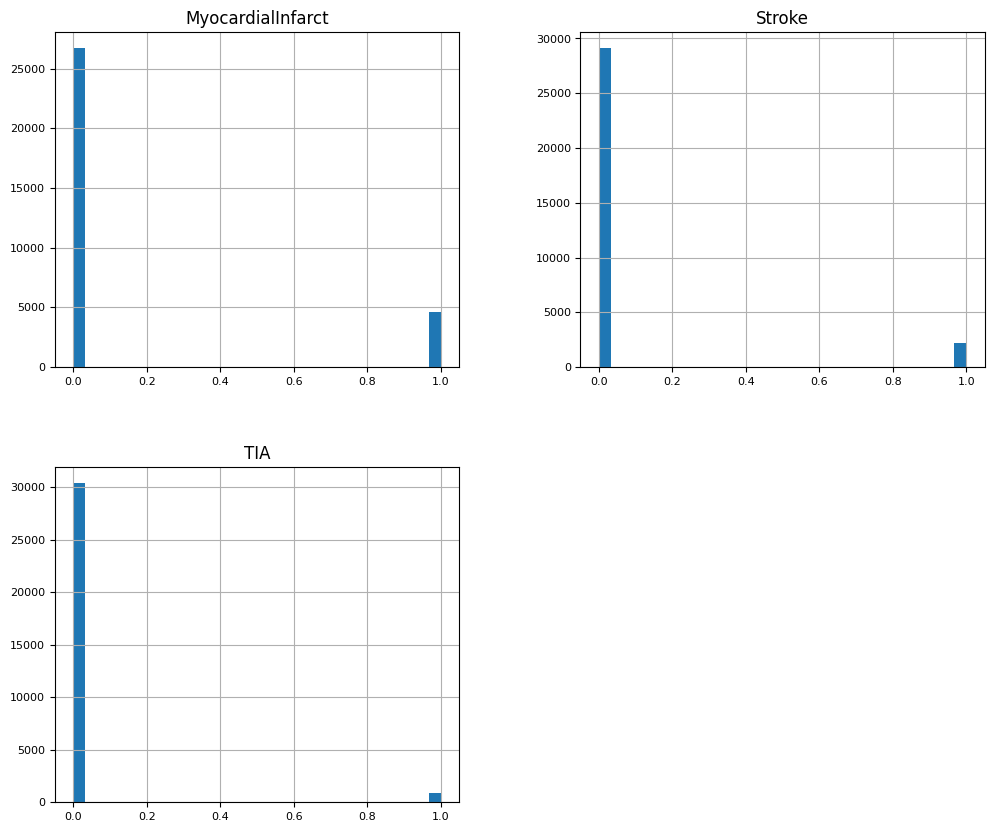

In [ ]:
dm[target_columns].hist(figsize=(12, 10), bins=30, xlabelsize=8, ylabelsize=8)

# The  data is visit-level.

## with the CPCSSN dataset, we are dealing with Longitudinal Data (the same patient appearing multiple times over years).

### Using Aggregation + GroupShuffleSplit.

# Aggregate dataset based on the patient ID


 Implementation Checklist Use :

 median for labs where you suspect outliers (BMI, HDL, TG).

 Use std (Standard Deviation) for A1c and sBP specifically; this is the "gold" predictor for diabetes complications.

 Use last to provide the model with the patient's "current" state before the end of the study.



* A1c	std & max	Glycemic Variability (the "swings") is a better predictor of microvascular damage (Retinopathy/Neuropathy) than a steady average.


* sBP	max & mean	High "peaks" in blood pressure cause immediate mechanical damage to kidney filters (CKD/ESRD) and eye vessels.

* BMI	median	BMI doesn't change as fast as blood sugar. median filters out the data entry errors common in busy primary care clinics.

* LDL max (Cardiovascular events), the highest cholesterol level ever reached is often what triggered the plaque buildup in the first place.

In [ ]:
# Perform the aggregation
dm_patient = dm.groupby('PID').agg({
    'Age_at_Exam': 'max',
    'Sex': 'first',

    # Vitals & Labs (Adding Mean and Max, ... for better prediction)
    # Vitals & Labs: Mean is good, but 'Max' or 'STD' captures "uncontrolled" spikes

    # Captures the "Typical" state (Median), "Worst" state (Max), and "Recent" state (Last)
    'A1c': ['median', 'max', 'std', 'last'],
    'sBP': ['mean', 'max', 'std', 'last'],
    'BMI': ['median', 'last'],

    # Metabolic profile
    'LDL': ['median', 'max'],
    'HDL': ['median'],
    'TG': ['median', 'max'],
    'Total_Cholesterol': ['max'],


    # Medications (Summing total exposure)
    'duration_b_R2_insulin_Days': 'sum',
    'total_b_R2_insulin_Records': 'sum',
    'duration_b_R2_statin_Days': 'sum',
    'total_b_R2_statin_Records': 'sum',
    'duration_b_R2_diuretic_Days': 'sum',
    'total_b_R2_diuretic_Records': 'sum',
    'duration_b_R2_ace-inhibitor_Days': 'sum',
    'total_b_R2_ace-inhibitor_Records': 'sum',
    'duration_b_R2_sulfonylurea_Days': 'sum',
    'total_b_R2_sulfonylurea_Records': 'sum',
    'duration_b_R2_arb_Days': 'sum',
    'total_b_R2_arb_Records': 'sum',
    'duration_b_R2_beta-blocker_Days': 'sum',
    'total_b_R2_beta-blocker_Records': 'sum',

    # Labels (Max ensures 1 if they ever had the complication)
   'MyocardialInfarct': 'max',
   'Stroke': 'max',
   'TIA': 'max',
   'NoCardio': 'max'
  })


# Fill missing values with 0
dm_patient = dm_patient.fillna(0)

# Flatten MultiIndex (Crucial!)
dm_patient.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in dm_patient.columns]

# Flatten the index so PID is a column again
dm_patient = dm_patient.reset_index()

In [ ]:
dm_patient.head(2)

,PID,Age_at_Exam_max,Sex_first,A1c_median,A1c_max,A1c_std,A1c_last,sBP_mean,sBP_max,sBP_std,...,duration_b_R2_sulfonylurea_Days_sum,total_b_R2_sulfonylurea_Records_sum,duration_b_R2_arb_Days_sum,total_b_R2_arb_Records_sum,duration_b_R2_beta-blocker_Days_sum,total_b_R2_beta-blocker_Records_sum,MyocardialInfarct_max,Stroke_max,TIA_max,NoCardio_max
0,1001000000001150,61,Male,6.8,9.3,0.770467,6.8,126.666667,146.0,9.612793,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,1001000000001343,72,Female,0.0,0.0,0.000000,0.0,132.260870,146.0,7.794038,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [ ]:
# Not preffered after aggregation

'''from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=dm['PID'])
)

X_train = X.iloc[train_idx]
X_test  = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]'''

"from sklearn.model_selection import GroupShuffleSplit\n\ngss = GroupShuffleSplit(\n    n_splits=1,\n    test_size=0.2,\n    random_state=42\n)\n\ntrain_idx, test_idx = next(\n    gss.split(X, y, groups=dm['PID'])\n)\n\nX_train = X.iloc[train_idx]\nX_test  = X.iloc[test_idx]\n\ny_train = y.iloc[train_idx]\ny_test  = y.iloc[test_idx]"

In [ ]:
int(dm_patient['PID'].duplicated().sum())


0

#### Alternative approach (better for prediction timing)

Instead of aggregating mean, using LAST observation before outcome

This is called:

Index date design

Used in:

• Lancet Digital Health
• Nature Medicine
• CPCSSN publications

In [ ]:
dm.groupby('PID').size().value_counts()


,count
1,3589
2,3177
3,2511
4,2257
5,1788
...,...
143,1
178,1
389,1
151,1


# Define features and targets (No Leakage)

In [ ]:
# Separate Features and Targets

target_columns = ['MyocardialInfarct', 'Stroke', 'TIA', 'NoCardio']

target_cols = [col + '_max' for col in target_columns]
X = dm_patient.drop(columns=['PID'] + target_cols)
y = dm_patient[target_cols]



In [ ]:
print(X.shape)
print(y.shape)

(25920, 32)
(25920, 4)


In [ ]:
X.shape[0] == y.shape[0]

True

In [ ]:
print(type(X), type(y))

<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.frame.DataFrame'>


In [ ]:
#X = X.values
#y = y.values

In [ ]:
X.columns

Index(['Age_at_Exam_max', 'Sex_first', 'A1c_median', 'A1c_max', 'A1c_std',
       'A1c_last', 'sBP_mean', 'sBP_max', 'sBP_std', 'sBP_last', 'BMI_median',
       'BMI_last', 'LDL_median', 'LDL_max', 'HDL_median', 'TG_median',
       'TG_max', 'Total_Cholesterol_max', 'duration_b_R2_insulin_Days_sum',
       'total_b_R2_insulin_Records_sum', 'duration_b_R2_statin_Days_sum',
       'total_b_R2_statin_Records_sum', 'duration_b_R2_diuretic_Days_sum',
       'total_b_R2_diuretic_Records_sum',
       'duration_b_R2_ace-inhibitor_Days_sum',
       'total_b_R2_ace-inhibitor_Records_sum',
       'duration_b_R2_sulfonylurea_Days_sum',
       'total_b_R2_sulfonylurea_Records_sum', 'duration_b_R2_arb_Days_sum',
       'total_b_R2_arb_Records_sum', 'duration_b_R2_beta-blocker_Days_sum',
       'total_b_R2_beta-blocker_Records_sum'],
      dtype='object')

In [ ]:
y.sample(4)

,MyocardialInfarct_max,Stroke_max,TIA_max,NoCardio_max
20863,0.0,0.0,0.0,0
22514,0.0,0.0,0.0,0
19834,0.0,0.0,0.0,0
4880,0.0,0.0,0.0,1


In [ ]:
for col in y.columns:
    print(col, y[col].unique())

MyocardialInfarct_max [0. 1.]
Stroke_max [0. 1.]
TIA_max [0. 1.]
NoCardio_max [0 1]


In [ ]:
y.head(2)

,MyocardialInfarct_max,Stroke_max,TIA_max,NoCardio_max
0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,0


In [ ]:
# Convert 4 one-hot columns into single integer label
y_label = np.argmax(y, axis=1)  # 0,1,2,3

In [ ]:
mask_all_zero = (ps['MyocardialInfarct']==0) & (ps['Stroke']==0) & (ps['TIA']==0) & (ps['NoCardio']==0)
print(ps[mask_all_zero])

Empty DataFrame
Columns: [Age_at_Exam, Sex, Diabetes, sBP, BMI, A1c, FBS, LDL, HDL, TG, Total_Cholesterol, duration_b_R2_insulin_Days, total_b_R2_insulin_Records, duration_b_R2_statin_Days, total_b_R2_statin_Records, duration_b_R2_diuretic_Days, total_b_R2_diuretic_Records, duration_b_R2_ace-inhibitor_Days, total_b_R2_ace-inhibitor_Records, duration_b_R2_sulfonylurea_Days, total_b_R2_sulfonylurea_Records, duration_b_R2_arb_Days, total_b_R2_arb_Records, duration_b_R2_beta-blocker_Days, total_b_R2_beta-blocker_Records, MyocardialInfarct, Stroke, TIA, NoCardio, PID]
Index: []

[0 rows x 30 columns]


In [ ]:
# Suppose your encoded column is y_encoded (Series)
num_minus_ones = (y_encoded == -1).sum()

print(f"Number of rows with -1: {num_minus_ones}")

Number of rows with -1: 0


In [ ]:
y.iloc[38, :]

,38
MyocardialInfarct_max,0.0
Stroke_max,0.0
TIA_max,0.0
NoCardio_max,1.0


In [ ]:
y_encoded.iloc[38]

np.int64(3)

In [ ]:
y_encoded[y_encoded == -1]

,0
0,-1
1,-1
2,-1
3,-1
4,-1
...,...
25915,-1
25916,-1
25917,-1
25918,-1


In [ ]:
ps[['MyocardialInfarct','Stroke','TIA','NoCardio']].sum(axis=1)

,0
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
808916,0.0
808917,0.0
808918,0.0
808919,0.0


In [ ]:
ps[['MyocardialInfarct','Stroke','TIA']].isna().sum()

,0
MyocardialInfarct,706185
Stroke,706185
TIA,706185


array([[<Axes: title={'center': 'label'}>]], dtype=object)

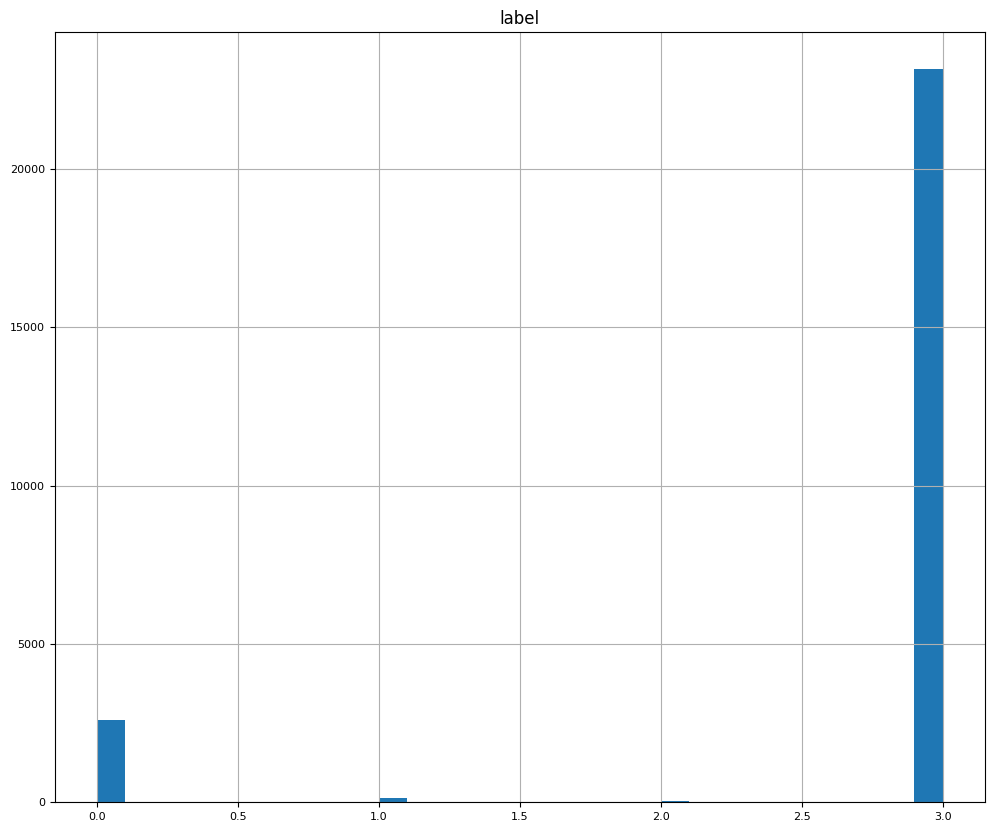

In [ ]:
y_label.hist(figsize=(12, 10), bins=30, xlabelsize=8, ylabelsize=8)

# EDA

##  Classes Frequencies Comparison

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=y_label['label'],
    palette="viridis"
)

plt.title("Distribution of Cardiovascular Outcomes")

plt.xlabel("Class")

plt.ylabel("Number of Patients")

plt.xticks(
    ticks=[0,1,2,3],
    labels=["MyocardialInfarct", "Stroke", "TIA", "NoCardio"]
)

plt.show()

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

<Figure size 800x500 with 0 Axes>

In [ ]:
X.shape

(25920, 32)

In [ ]:
y_label.shape

(25920, 1)

# Predictors Distributions



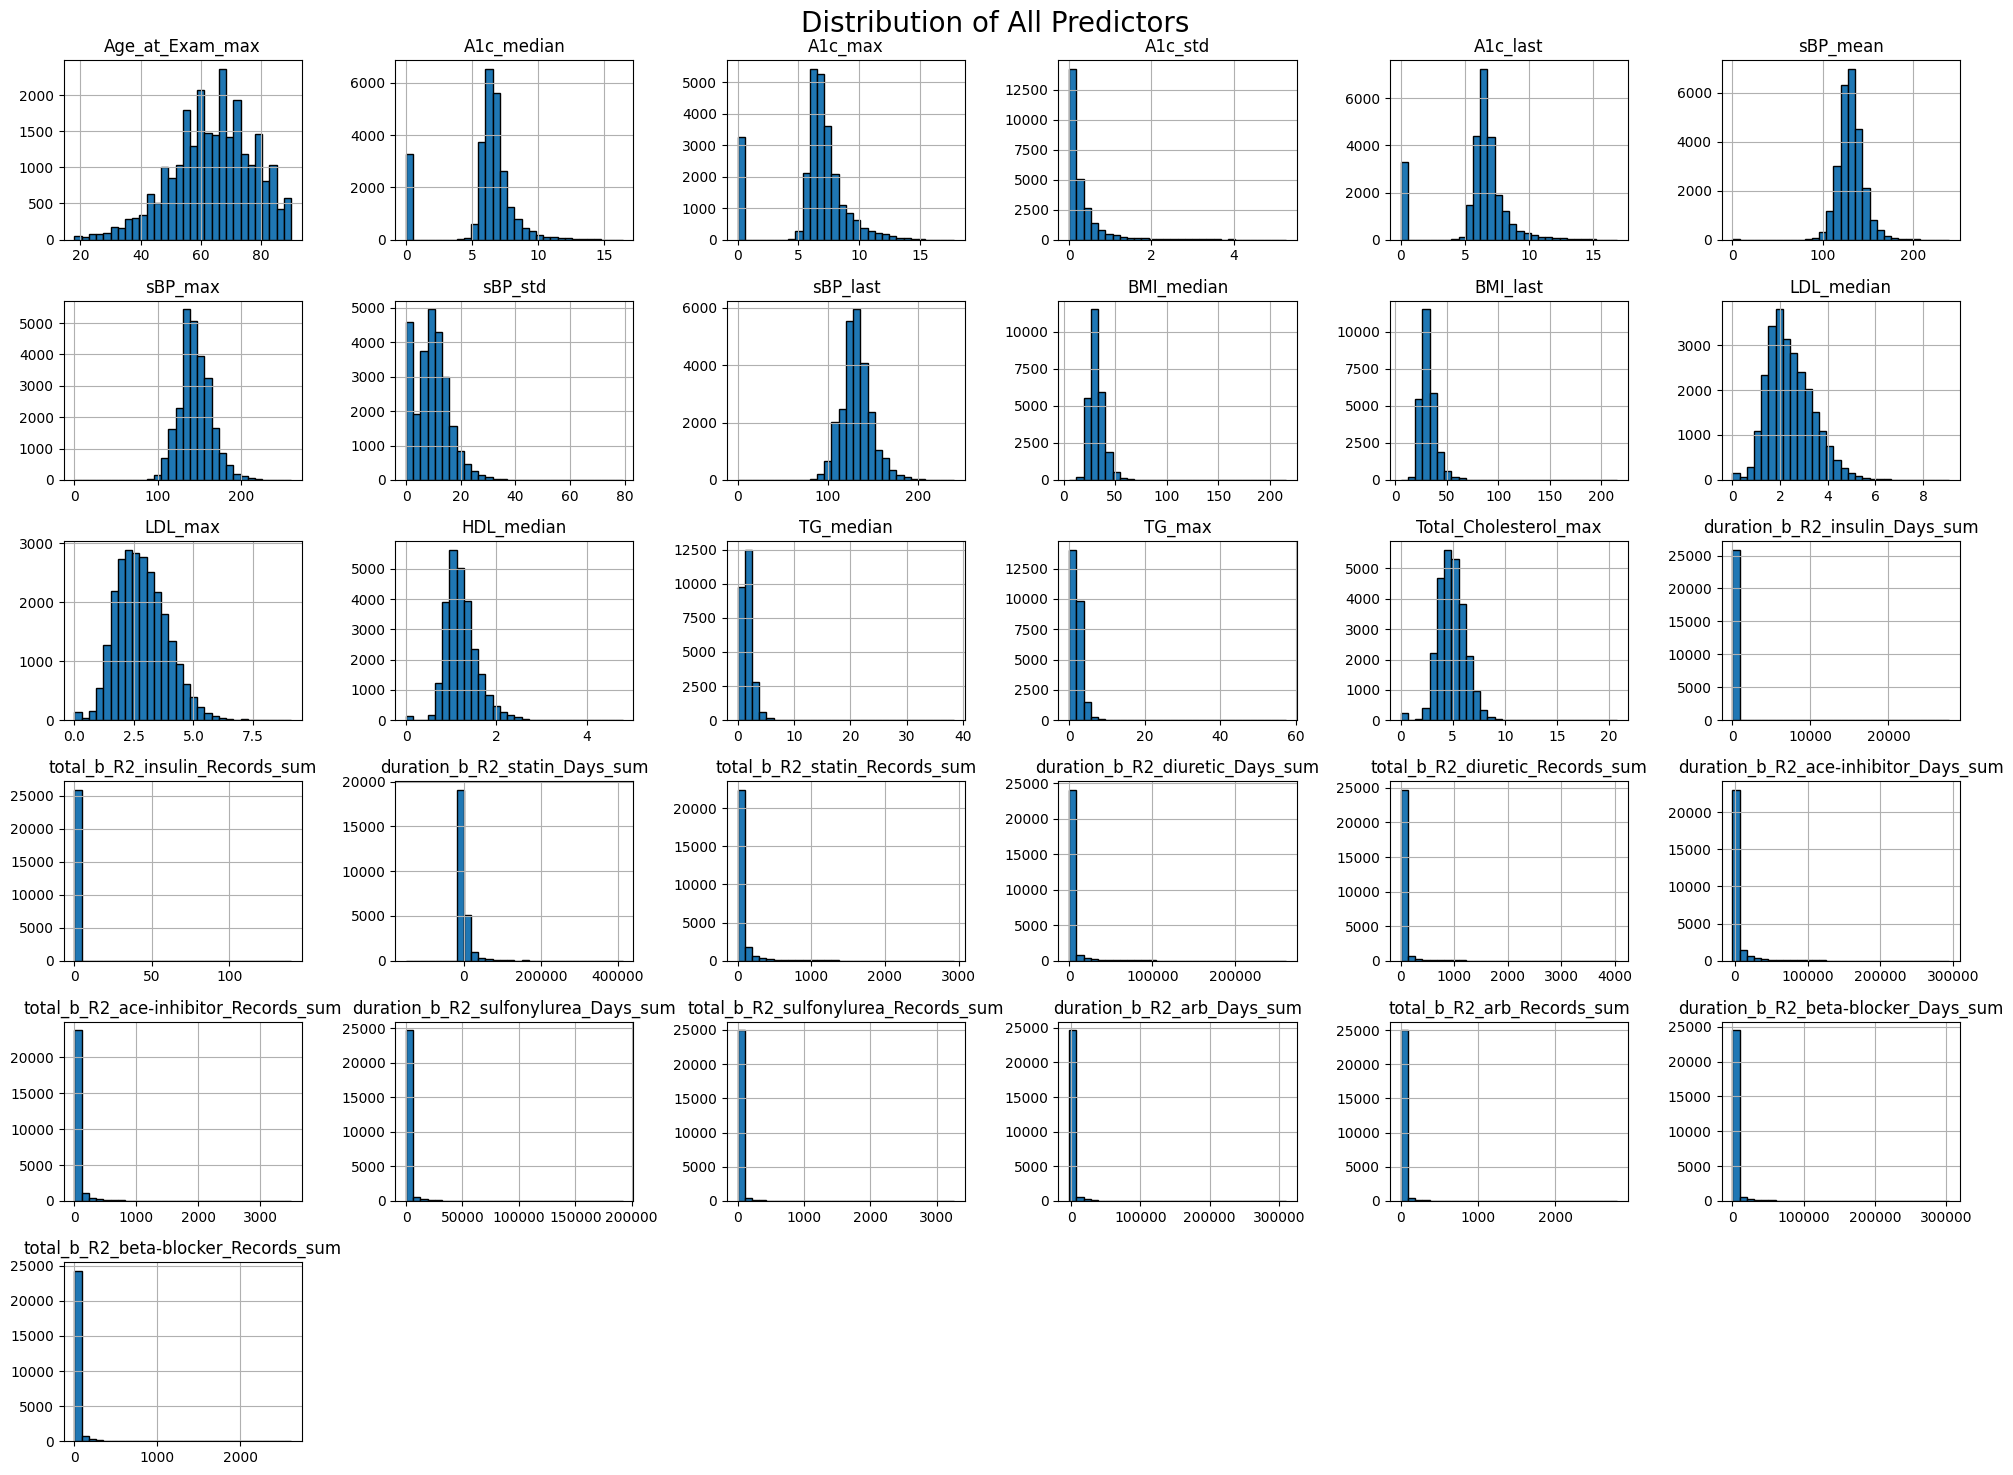

In [ ]:
X_df = pd.DataFrame(X)

X_df.hist(
    bins=30,
    figsize=(20,15),
    layout=(6,6),
    edgecolor="black"
)

plt.suptitle("Distribution of All Predictors", fontsize=20)

plt.tight_layout()

plt.show()

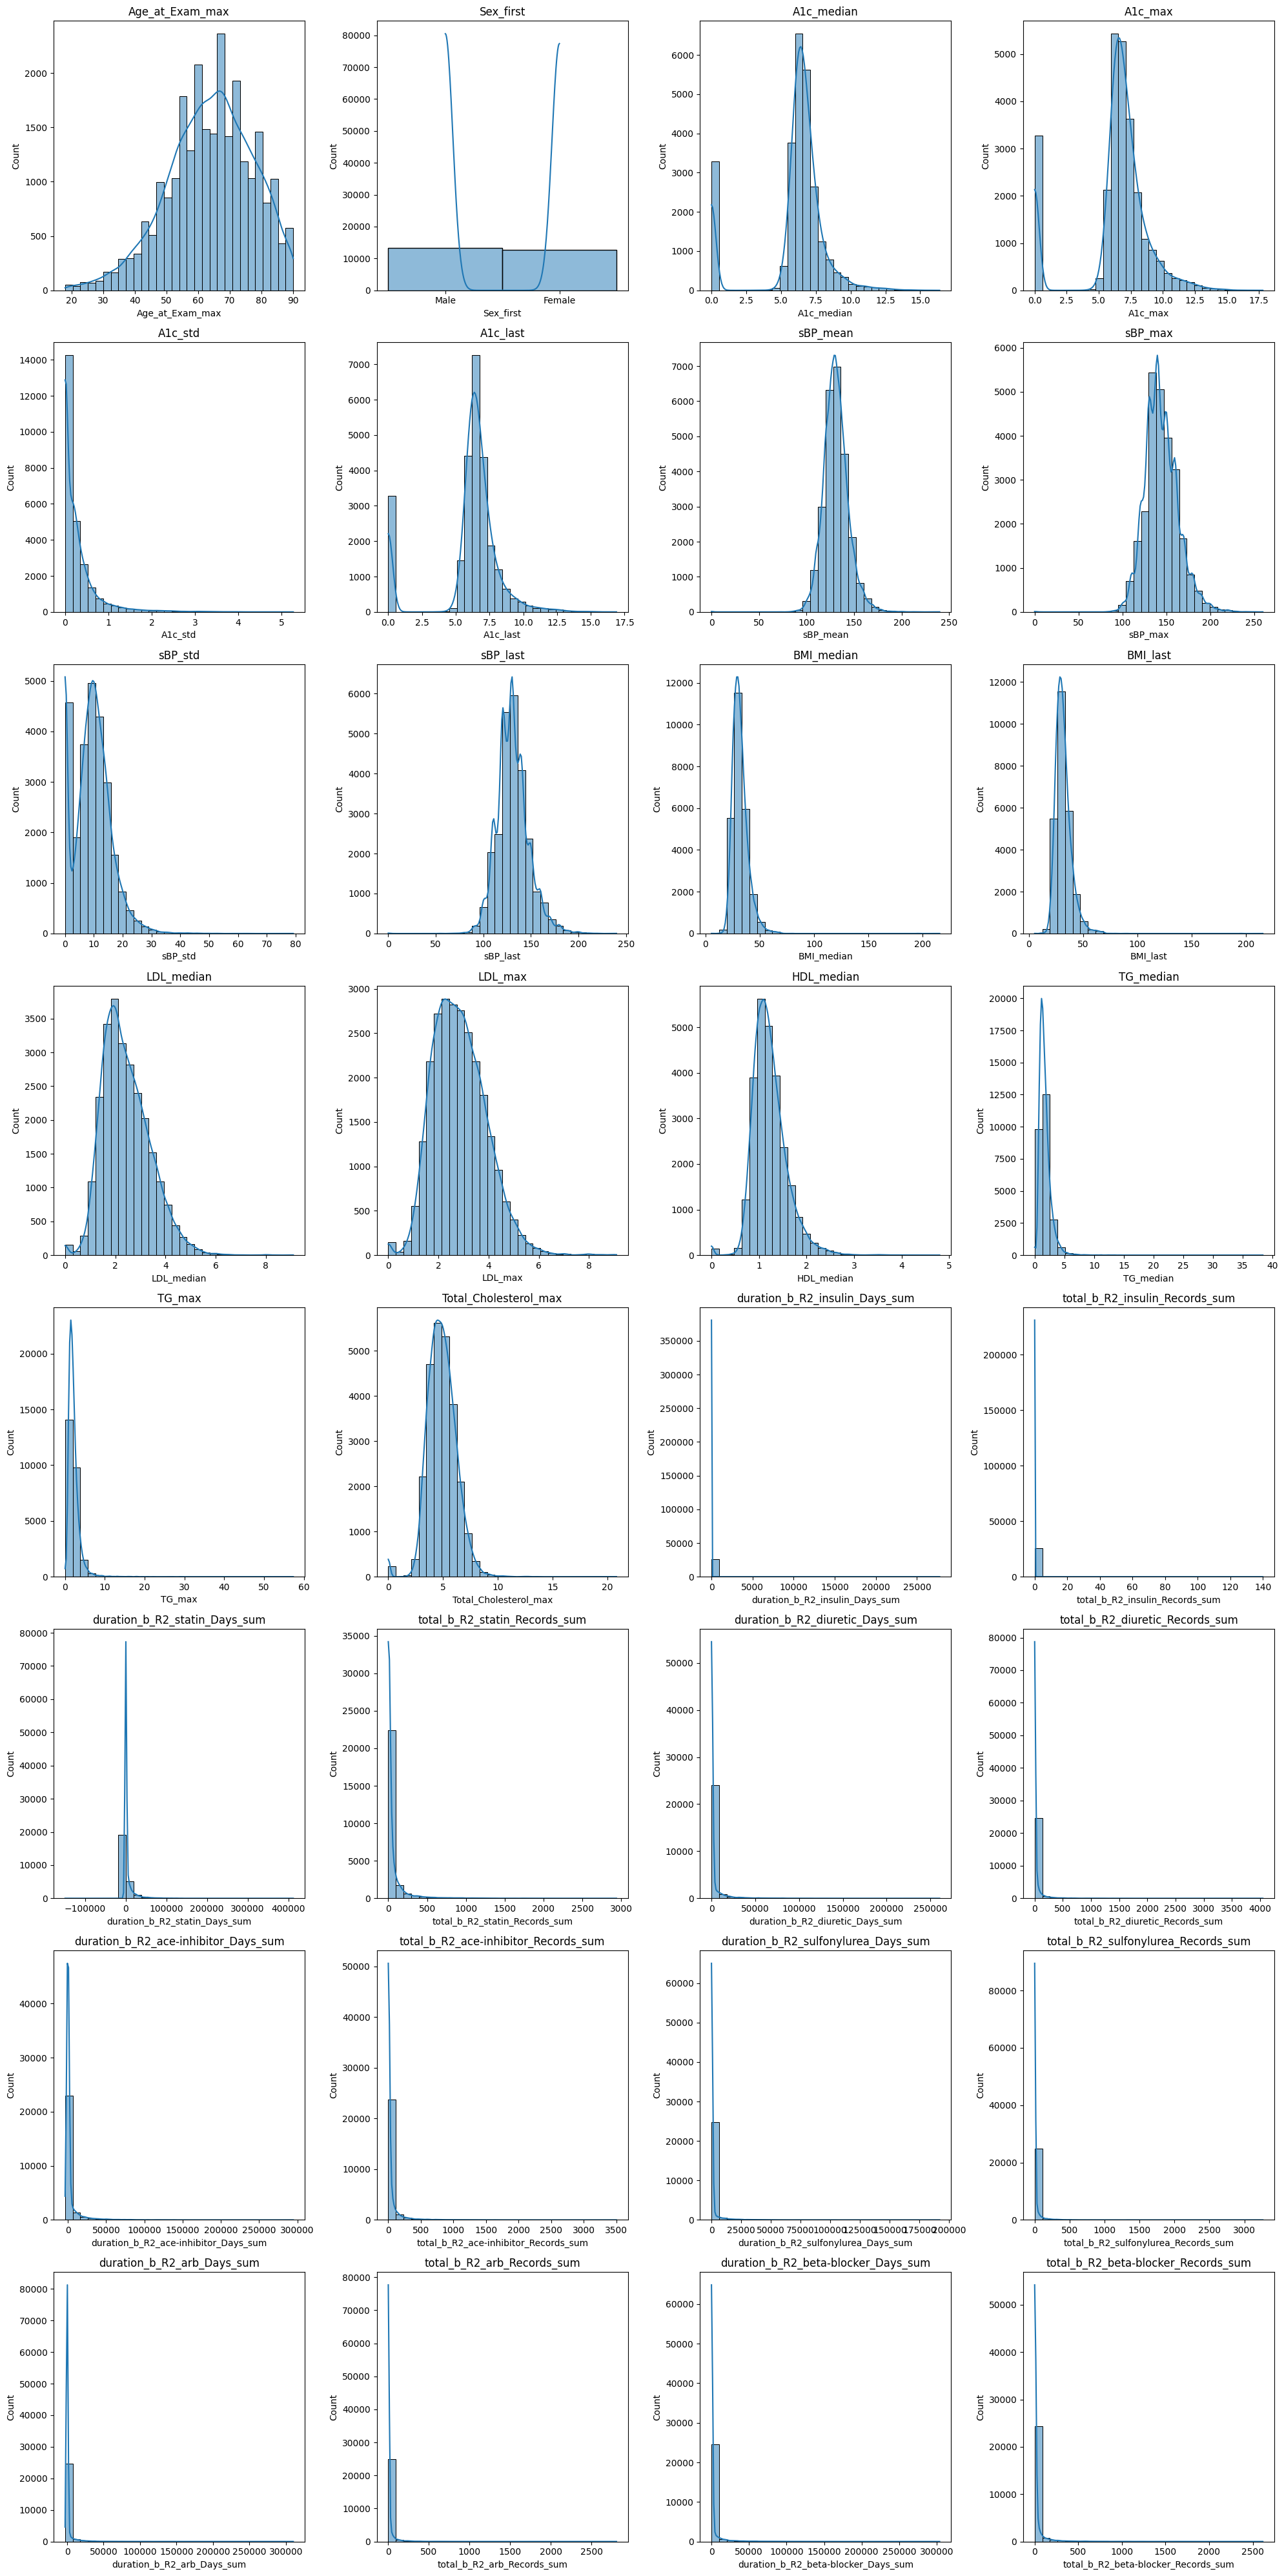

In [ ]:
import math


cols = X_df.columns

n_cols = 4

n_rows = math.ceil(len(cols)/n_cols)


plt.figure(figsize=(20, 5*n_rows))


for i, col in enumerate(cols):

    plt.subplot(n_rows, n_cols, i+1)

    sns.histplot(
        X_df[col],
        bins=30,
        kde=True
    )

    plt.title(col)


plt.tight_layout()

plt.show()


# Barplot of complications individually


In [ ]:

for col in y.columns:
    non_zero_count = (y[col] != 0).sum()
    print(f"Column: {col}")
    print(non_zero_count)
    print("-"*30)


Column: MyocardialInfarct_max
355
------------------------------
Column: Stroke_max
163
------------------------------
Column: TIA_max
62
------------------------------
Column: NoCardio_max
2229
------------------------------


Column: MyocardialInfarct_max
355
------------------------------
Column: Stroke_max
163
------------------------------
Column: TIA_max
62
------------------------------
Column: NoCardio_max
2229
------------------------------


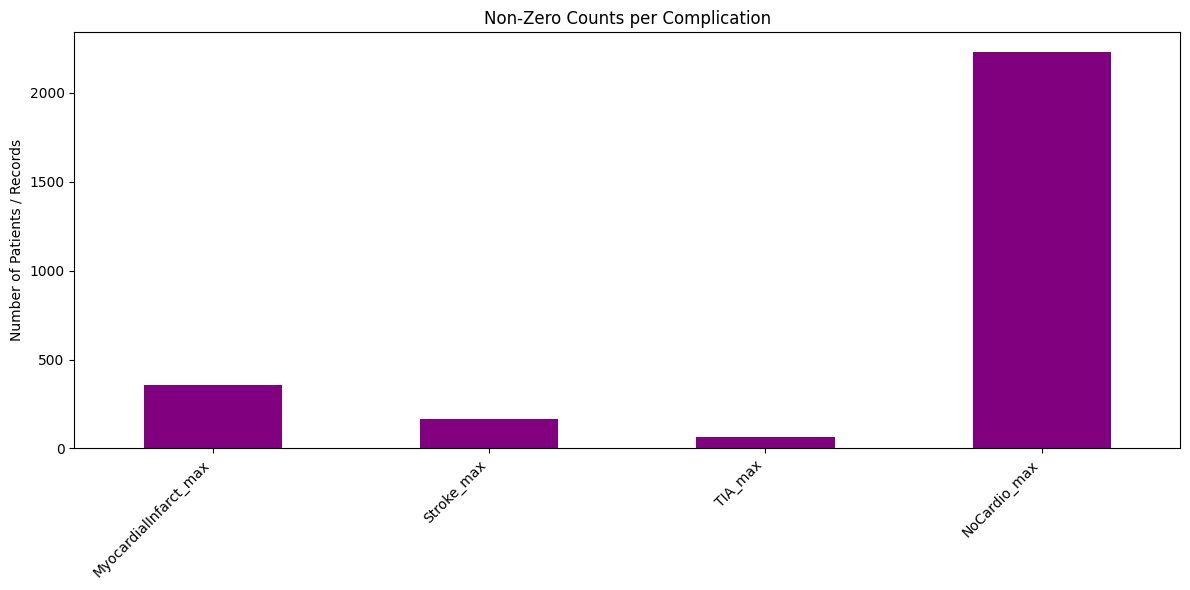

In [ ]:
non_zero_counts = (y != 0).sum()

# Print counts
for col, count in non_zero_counts.items():
    print(f"Column: {col}")
    print(count)
    print("-"*30)

# Plot bar chart
plt.figure(figsize=(12,6))
non_zero_counts.plot(kind='bar', color='purple')
plt.ylabel("Number of Patients / Records")
plt.title("Non-Zero Counts per Complication")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
y.sample(10)

,MyocardialInfarct_max,Stroke_max,TIA_max,NoCardio_max
10920,0.0,0.0,0.0,0
6948,0.0,0.0,0.0,0
18650,0.0,0.0,0.0,0
5964,0.0,0.0,0.0,1
3104,0.0,0.0,0.0,0
21062,0.0,0.0,0.0,1
3775,0.0,0.0,0.0,0
2608,0.0,0.0,0.0,0
2328,0.0,0.0,0.0,0
7815,0.0,0.0,0.0,1


In [ ]:
y.isna().sum()

,0
MyocardialInfarct_max,0
Stroke_max,0
TIA_max,0
NoCardio_max,0


In [ ]:
target_map = { 'MyocardialInfarct_max': 0,
   'Stroke_max': 1,
   'TIA_max': 2,
   'NoCardio_max': 3
  }


In [ ]:
# Function to get the numeric label for each row

def encode_row(row):
    # Find the column(s) where the value is 1
    ones = row[row == 1].index.tolist()
    if len(ones) == 0:
        return -1  # Optional: for rows with no positive label
    # Map to numeric code (take first if multiple)
    return target_map[ones[0]]

# Apply function row-wise
y_encoded = y.apply(encode_row, axis=1)

print(y_encoded.unique())

[-1  3  0  1  2]


In [ ]:
.map({...})

SyntaxError: invalid syntax (ipython-input-3517408337.py, line 1)

# Train–test split (patient-level)

## LogicReason:

Standard random splitting often results in "label sparsity" in the test set, where rare but critical complications (like Amputation or ESRD) may not appear at all, making the model evaluation impossible.

## Strategy:

 We use Iterative Stratification on the aggregated patient-level data. This ensures the complex combinations of multiple complications are distributed proportionally ($70/15/15$) across all sets, maintaining the biological integrity of the cohort.

#### Iterative stratification  : 70 / 15 / 15 patient-level split


Pattern Preservation: iterative_train_test_split (Result A) doesn't just look at one label at a time. It tries to ensure that if someone has the "Triple Threat" (Retinopathy + Neuropathy + Nephropathy), that specific combination exists in both your training and testing sets.



## Simple Split for memory sake

### Step 1: Train (70%) vs Temp (30%)
### Step 2:  Split temp → 15% validation / 15% test


In [ ]:


# Step 1: 70% Train, 30% Temporary (which will become 15% Val and 15% Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_label,
    test_size=0.30,
    random_state=42
)

# Step 2: Split the 30% Temp into two equal halves (15% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42
)

# Validation: Verify proportion of complications across sets
print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")
# print("Check stratification (Retinopathy %):", y_train[:,0].mean(), y_test[:,0].mean())

Train size: 18144 | Val size: 3888 | Test size: 3888


In [ ]:
# Validation Check
# Ensure the rarest labels (like Amputation) actually appear in the Test set
# axis=0 tells it to sum each column individually
print(y_test.sum(axis=0))

1001


In [ ]:
# or Convert back to DataFrame using your list of target columns
y_test_df = pd.DataFrame(y_test, columns=target_cols)

#  .sum() will give you the 7 distinct counts
print(y_test_df.sum())

ValueError: Shape of passed values is (3888, 1), indices imply (3888, 4)

In [ ]:


print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 18144 | Val: 3888 | Test: 3888


# Preprocessing (nulls + encoding)





In [ ]:
# Convert X_train to DataFrame once to ensure consistency
X_df = pd.DataFrame(X_train)

# Better selection logic: captures all numbers and all categories/strings
numeric_cols = X_df.select_dtypes(include=[np.number]).columns
categorical_cols = X_df.select_dtypes(include=['object', 'category']).columns

preprocessor = ColumnTransformer(
    transformers=[
        # Removed StandardScaler as it's not needed for XGBoost
        ('num', SimpleImputer(strategy='median'), numeric_cols),
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_cols)
    ])

# Model Structure: Multi-Class XGBoost



In [ ]:
num_classes = 4

model = XGBClassifier(
    objective='multi:softprob',   # multiclass probability output
    num_class=num_classes,        # number of classes
    eval_metric='mlogloss',
    random_state=42,
    enable_categorical=True
)

# pipeline

In [ ]:
pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', model)])


# Force string columns to be the 'category' data type

In [ ]:
X.Sex_first.sample(8)

,Sex_first
19387,Male
12985,Male
2430,Female
7199,Male
8780,Female
23238,Male
15215,Female
6560,Male


# Creat a Subset of Train Data

In [ ]:
subset_size = 6000
# Create stratification label (at least one complication vs none)
train_stratify_label = (y_train.sum(axis=1) > 0).astype(int)

# Generate stratified indices
rng = np.random.RandomState(42)

subset_idx = []

for label in np.unique(train_stratify_label):

    label_idx = np.where(train_stratify_label == label)[0]

    n_label_subset = int(subset_size * len(label_idx) / len(train_stratify_label))

    subset_idx.extend(
        rng.choice(label_idx, n_label_subset, replace=False)
    )

subset_idx = np.array(subset_idx)

# Apply subset
X_train_subset = X_train[subset_idx]
y_train_subset = y_train[subset_idx]

print(X_train_subset.shape)
print(y_train_subset.shape)

KeyError: "None of [Index([15969,  9292,  8580,  1567, 12652,   671,  2306,  3066, 16601, 10057,\n       ...\n        6239, 11723,  3946, 12260,  5819,  9132, 11883, 11839, 16651,  3927],\n      dtype='int64', length=5999)] are in the [columns]"

# 5-fold stratified CV (TRAINING ONLY)


Since this is a Multiclass Classification problem specifically designed for Longitudinal EHR data, we have to account for the fact that medical datasets are usually highly imbalanced (many more "NoCardio" cases than "Stroke" or "MI").


In [ ]:
import gc
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    recall_score,
    precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    log_loss
)


# Prepare labels


#y_labels = np.argmax(y, axis=1) if len(y.shape) > 1 else y

class_names = [
    'NoCardio',
    'MyocardialInfarct',
    'Stroke',
    'TIA'
]


# Cross Validation


skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

all_scores = []
total_cm = np.zeros((4,4))



# CV LOOP

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_labels)):

    print(f"\n================ FOLD {fold+1} ================")

    X_tr = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_tr = y_labels[train_idx]
    y_val = y_labels[val_idx]


    # Train
    model.fit(X_tr, y_tr)


    # Predict
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)


    # METRICS


    auc_macro = roc_auc_score(
        y_val,
        y_prob,
        multi_class="ovr",
        average="macro"
    )

    auc_weighted = roc_auc_score(
        y_val,
        y_prob,
        multi_class="ovr",
        average="weighted"
    )

    auc_micro = roc_auc_score(
        y_val,
        y_prob,
        multi_class="ovr",
        average="micro"
    )


    f1_macro = f1_score(
        y_val,
        y_pred,
        average="macro"
    )

    precision_macro = precision_score(
        y_val,
        y_pred,
        average="macro"
    )

    recall_macro = recall_score(
        y_val,
        y_pred,
        average="macro"
    )

    balanced_acc = balanced_accuracy_score(
        y_val,
        y_pred
    )

    loss = log_loss(
        y_val,
        y_prob
    )


    # Per-class clinical sensitivity
    recall_per_class = recall_score(
        y_val,
        y_pred,
        average=None
    )


    # Confusion matrix
    cm = confusion_matrix(
        y_val,
        y_pred
    )

    total_cm += cm


    # Store
    fold_result = {

        "AUC_macro": auc_macro,
        "AUC_micro": auc_micro,
        "AUC_weighted": auc_weighted,

        "F1_macro": f1_macro,

        "Precision_macro": precision_macro,

        "Recall_macro": recall_macro,

        "Balanced_accuracy": balanced_acc,

        "Log_loss": loss,

        "Recall_NoCardio": recall_per_class[0],
        "Recall_MI": recall_per_class[1],
        "Recall_Stroke": recall_per_class[2],
        "Recall_TIA": recall_per_class[3]

    }

    all_scores.append(fold_result)



    # PRINT FOLD RESULTS


    print("\nAUC Macro:", auc_macro)
    print("AUC Micro:", auc_micro)
    print("F1 Macro:", f1_macro)
    print("Balanced Acc:", balanced_acc)

    print("\nPer-class Recall:")

    for i, name in enumerate(class_names):

        print(name, ":", recall_per_class[i])


    print("\nConfusion Matrix")

    print(cm)


    gc.collect()



# FINAL RESULTS


results = pd.DataFrame(all_scores)

print("\n\n================ FINAL RESULTS ================")

print("\nMEAN RESULTS:")

print(results.mean())


print("\nBEST ROC-AUC MACRO:")

print(results["AUC_macro"].max())


print("\nTOTAL CONFUSION MATRIX:")

print(total_cm)

NameError: name 'y_labels' is not defined


=== FINAL CROSS-VALIDATION RESULTS ===
Balanced_Acc     0.250319
F1_Macro         0.237570
AUC_Macro        0.571415
Recall_MI        0.000000
Recall_Stroke    0.000000
dtype: float64


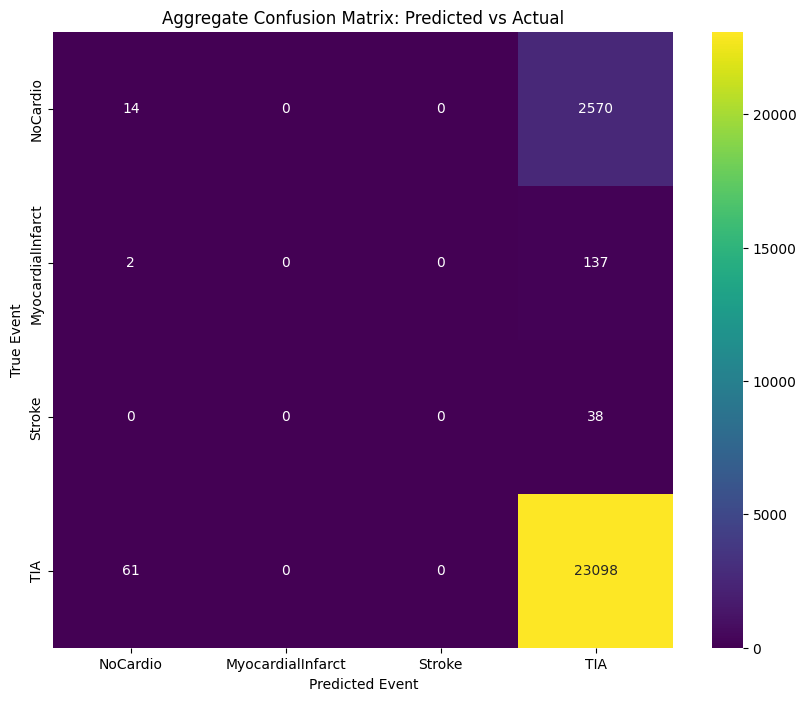

In [ ]:
# --- Reporting ---
summary = pd.DataFrame(fold_metrics).mean()
print("\n=== FINAL CROSS-VALIDATION RESULTS ===")
print(summary)

# Visualizing the confusion matrix for error analysis
plt.figure(figsize=(10, 8))
sns.heatmap(total_cm, annot=True, fmt='g', cmap='viridis',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Aggregate Confusion Matrix: Predicted vs Actual')
plt.ylabel('True Event')
plt.xlabel('Predicted Event')
plt.show()

In [ ]:
y_labels.shape

(25920,)

# Prediction on Test

In [ ]:
# Fix test dtype

X_test["Sex_first"] = X_test["Sex_first"].map({
    "Male": 0,
    "Female": 1
}).astype("int8")

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [ ]:
# TEST SET PREDICTION

# Train final model on FULL training data
model.fit(X_train, y_train)


# Predict test
y_test_pred = model.predict(X_test)

y_test_prob = model.predict_proba(X_test)


print("Prediction complete.")

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:Sex_first: object

# Test Set Metrics

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    recall_score,
    precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    log_loss,
    classification_report
)


# METRICS

auc_macro = roc_auc_score(
    y_test,
    y_test_prob,
    multi_class="ovr",
    average="macro"
)

auc_micro = roc_auc_score(
    y_test,
    y_test_prob,
    multi_class="ovr",
    average="micro"
)

auc_weighted = roc_auc_score(
    y_test,
    y_test_prob,
    multi_class="ovr",
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro"
)

precision = precision_score(
    y_test,
    y_test_pred,
    average="macro"
)

recall = recall_score(
    y_test,
    y_test_pred,
    average="macro"
)

balanced_acc = balanced_accuracy_score(
    y_test,
    y_test_pred
)

loss = log_loss(
    y_test,
    y_test_prob
)


print("\n================ TEST RESULTS ================")

print("ROC-AUC Macro:", auc_macro)

print("ROC-AUC Micro:", auc_micro)

print("ROC-AUC Weighted:", auc_weighted)

print("F1 Macro:", f1)

print("Precision Macro:", precision)

print("Recall Macro:", recall)

print("Balanced Accuracy:", balanced_acc)

print("Log Loss:", loss)

ValueError: Classification metrics can't handle a mix of multilabel-indicator and multiclass targets

# Confusion Matrix HEatmap

In [ ]:
class_names = [
    "NoCardio",
    "MyocardialInfarct",
    "Stroke",
    "TIA"
]

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix — Test Set")

plt.xlabel("Predicted")

plt.ylabel("True")

plt.show()

# ROC Curve Plot

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


# Binarize labels
y_test_bin = label_binarize(
    y_test,
    classes=[0,1,2,3]
)


plt.figure(figsize=(10,7))


for i, class_name in enumerate(class_names):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_test_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} AUC = {roc_auc:.3f}"
    )


# Micro average

fpr_micro, tpr_micro, _ = roc_curve(
    y_test_bin.ravel(),
    y_test_prob.ravel()
)

auc_micro_plot = auc(fpr_micro, tpr_micro)

plt.plot(
    fpr_micro,
    tpr_micro,
    linestyle="--",
    linewidth=3,
    label=f"Micro Average AUC = {auc_micro_plot:.3f}"
)


plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve — Test Set")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [ ]:
# --- Visualization & Final Reporting ---
df_results = pd.DataFrame(all_fold_results)
print("\nFINAL CROSS-VALIDATION AVERAGES:")
print(df_results.drop(columns='fold').mean())

# Heatmap for Medical Error Analysis
plt.figure(figsize=(10, 7))
sns.heatmap(aggregated_cm, annot=True, fmt='g', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Condition')
plt.ylabel('Actual Condition')
plt.title('Clinical Diagnostic Confusion Matrix (Aggregated)')
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold


skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

skf.split(X_train, y_train)




<generator object _BaseKFold.split at 0x7cdfb992e790>

# Evaluation Scores

In [ ]:
print("\n\n=========== FINAL RESULTS ===========")

mean_f1 = np.mean([s["f1_macro"] for s in scores])
mean_recall = np.mean([s["recall_macro"] for s in scores])
mean_hamming = np.mean([s["hamming"] for s in scores])
mean_auc_macro = np.mean([s["roc_auc_macro"] for s in scores])
mean_auc_micro = np.mean([s["roc_auc_micro"] for s in scores])
mean_lrap = np.mean([s["lrap"] for s in scores])

best_auc_macro = np.max([s["roc_auc_macro"] for s in scores])
best_auc_micro = np.max([s["roc_auc_micro"] for s in scores])

print("\nAverage Metrics:")
print(f"Mean F1 (macro): {mean_f1:.3f}")
print(f"Mean Recall (macro): {mean_recall:.3f}")
print(f"Mean Hamming: {mean_hamming:.3f}")
print(f"Mean ROC-AUC (macro): {mean_auc_macro:.3f}")
print(f"Mean ROC-AUC (micro): {mean_auc_micro:.3f}")
print(f"Mean LRAP: {mean_lrap:.3f}")

print("\nBest ROC-AUCs:")
print(f"Best ROC-AUC (macro): {best_auc_macro:.3f}")
print(f"Best ROC-AUC (micro): {best_auc_micro:.3f}")



=========== FINAL RESULTS ===========

Average Metrics:
Mean F1 (macro): 0.000
Mean Recall (macro): 0.000
Mean Hamming: 0.002
Mean ROC-AUC (macro): nan
Mean ROC-AUC (micro): 0.742
Mean LRAP: 0.996

Best ROC-AUCs:
Best ROC-AUC (macro): nan
Best ROC-AUC (micro): 0.800


# Train Final Model

In [ ]:
pipeline.fit(X_train_subset, y_train_subset)

gc.collect()


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


120

# Predict Test Set

In [ ]:
y_prob_test = pipeline.predict_proba(X_test)

y_prob_matrix_test = np.array([p[:,1] for p in y_prob_test]).T

print(y_prob_matrix_test.shape)

(3888, 7)


# Confusion Matrix on the test Data

In [ ]:
from sklearn.metrics import confusion_matrix

y_test_pred = pipeline.predict(X_test)

cm_test = confusion_matrix(
    y_test.ravel(),
    y_test_pred.ravel()
)

print(cm_test)

[[27176     0]
 [   40     0]]


# Confusion Matrix Heatmap (per complication)

In [ ]:
y[0]

array([0., 0., 0., 0., 0., 0., 0.])

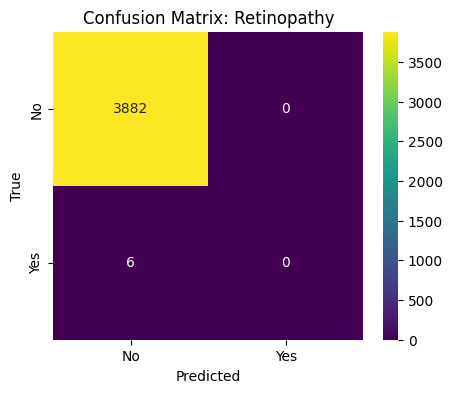

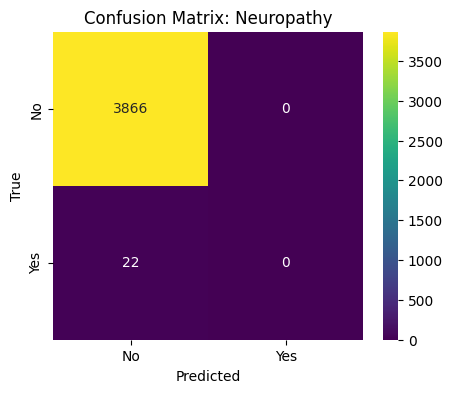

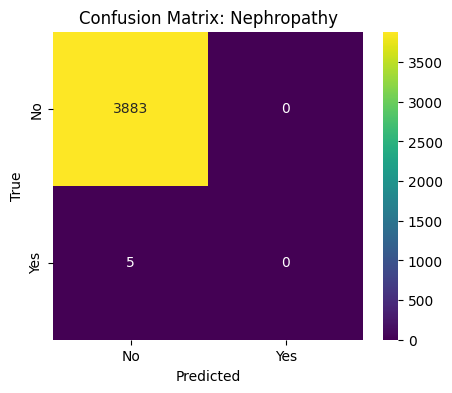

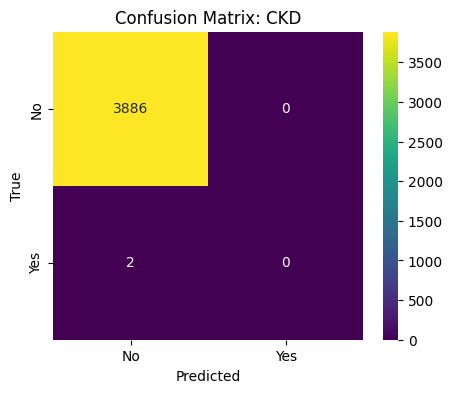

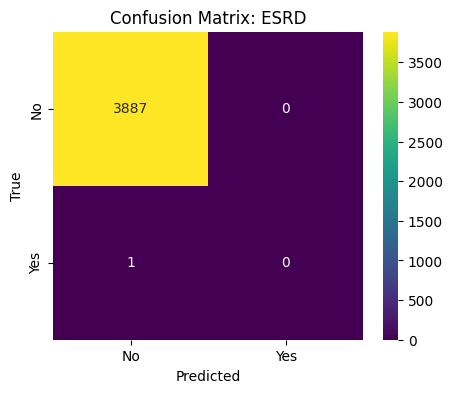

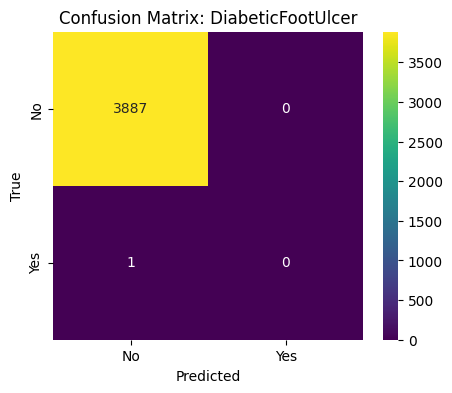

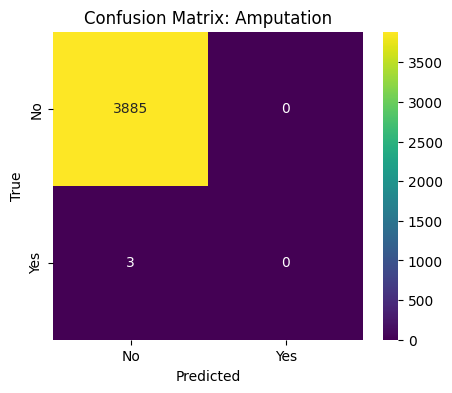

In [ ]:
# y_test and y_pred must be numpy arrays
y_test_np = y_test
y_pred_np = y_test_pred  # already NumPy from pipeline.predict

# complication names
label_names = target_columns

cm = multilabel_confusion_matrix(y_test_np, y_pred_np)


for i, label in enumerate(label_names):

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm[i],
        annot=True,
        fmt="d",
        cmap="viridis",
        xticklabels=["No", "Yes"],
        yticklabels=["No", "Yes"]
    )

    plt.title(f"Confusion Matrix: {label}")
    plt.ylabel("True")
    plt.xlabel("Predicted")

    plt.show()

In [ ]:
# Create confusion matrix per target
for i, target in enumerate(target_columns):
    cm = confusion_matrix(y_test[:, i], y_test_pred[:, i])
    print(f"Confusion Matrix for {target}:\n{cm}\n")

Confusion Matrix for Retinopathy:
[[3882    0]
 [   6    0]]

Confusion Matrix for Neuropathy:
[[3866    0]
 [  22    0]]

Confusion Matrix for Nephropathy:
[[3883    0]
 [   5    0]]

Confusion Matrix for CKD:
[[3886    0]
 [   2    0]]

Confusion Matrix for ESRD:
[[3887    0]
 [   1    0]]

Confusion Matrix for DiabeticFootUlcer:
[[3887    0]
 [   1    0]]

Confusion Matrix for Amputation:
[[3885    0]
 [   3    0]]



# ROC Curve (per complication)

In [ ]:
y_prob_np = np.array(y_prob_matrix_test)


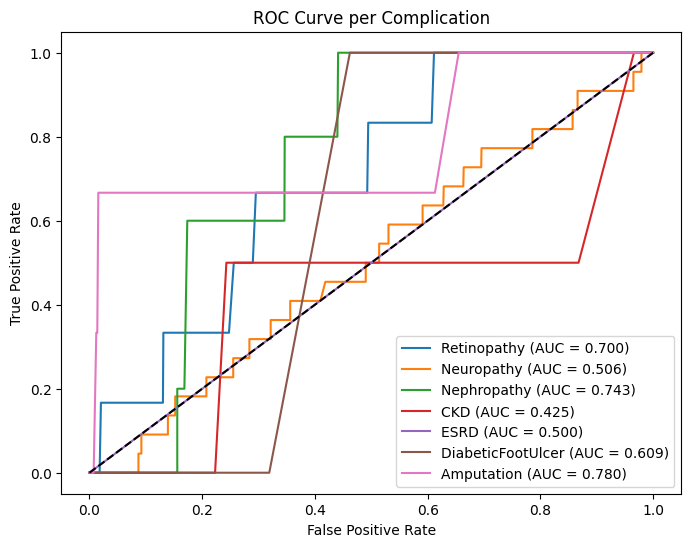

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for i, label in enumerate(label_names):
    fpr, tpr, _ = roc_curve(y_test_np[:, i], y_prob_np[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve per Complication")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# HyperParameter Tunning

In [ ]:
param_grid = {
    'model__estimator__n_estimators': [30, 50],
    'model__estimator__max_depth': [3, 5],
    'model__estimator__learning_rate': [0.01, 0.1],
    'model__estimator__subsample': [0.8, 1.0],
    'model__estimator__colsample_bytree': [0.8, 1.0]
}



search = RandomizedSearchCV(

    pipeline,

    param_distributions=param_grid,

    n_iter=5,          # NOT 10
    cv=3,              # NOT 5
    scoring= 'recall_macro',

    n_jobs=-1,          # MUST BE 1
    verbose=2,

    random_state=42

)

search.fit(X_sub, y_sub)